# 01 · Dataset exploration

Explores the clause dataset used to train and evaluate the LegalLens classifier (`data/datasets/clause_dataset.csv`, built by `scripts/build_datasets.py`).

Sources: project-authored seed clauses, CUAD v1 expert annotations mapped to the six LegalLens categories, and heading-derived weak labels from CUAD contracts (see `docs/DATASETS.md`).

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT))
import os; os.chdir(ROOT)

In [2]:
import pandas as pd
df = pd.read_csv('data/datasets/clause_dataset.csv')
print(df.shape)
df.head()

(4135, 4)


,clause,label,source,origin_label
0,Employee shall receive a monthly salary of Rs....,Payment,seed_authored,Payment
1,The Employer shall pay the Employee a gross an...,Payment,seed_authored,Payment
2,"The Tenant shall pay a monthly rent of Rs. 12,...",Payment,seed_authored,Payment
3,The Client shall pay the Service Provider the ...,Payment,seed_authored,Payment
4,All amounts payable under this Agreement are e...,Payment,seed_authored,Payment


## Label distribution by source

In [3]:
pd.crosstab(df['label'], df['source'], margins=True)

source,cuad_heading_weak,cuad_v1,seed_authored,All
label,,,,
Confidentiality,199,0,20,219
Dispute,183,150,20,353
Liability,188,392,20,600
Others,0,1750,31,1781
Payment,198,358,20,576
Termination,184,402,20,606
All,952,3052,131,4135


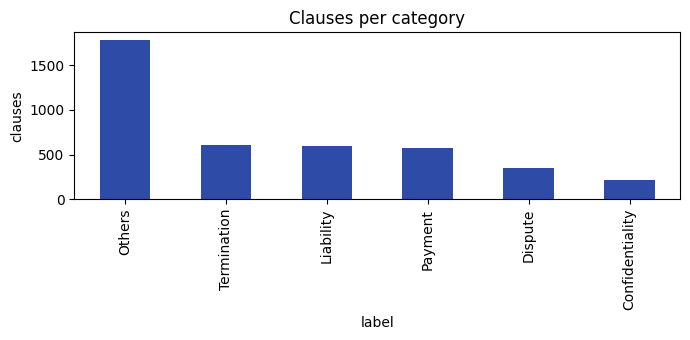

In [4]:
import matplotlib.pyplot as plt
ax = df['label'].value_counts().plot.bar(color='#2F4BA8', figsize=(7,3.5))
ax.set_ylabel('clauses'); ax.set_title('Clauses per category'); plt.tight_layout(); plt.show()

## Clause length

In [5]:
df['words'] = df['clause'].str.split().str.len()
df.groupby('label')['words'].describe()[['count','mean','50%','max']].round(1)

,count,mean,50%,max
label,,,,
Confidentiality,219.0,98.5,90.0,232.0
Dispute,353.0,57.7,37.0,235.0
Liability,600.0,77.2,67.0,227.0
Others,1781.0,54.5,44.0,241.0
Payment,576.0,70.2,52.0,264.0
Termination,606.0,61.9,48.0,249.0


## CUAD label mapping
Which original CUAD categories feed each LegalLens category (expert-labelled rows only).

In [6]:
cuad = df[df['source'] == 'cuad_expert']
cuad.groupby(['label', 'origin_label']).size().rename('rows').reset_index().sort_values(['label','rows'], ascending=[True, False]).groupby('label').head(4)

,label,origin_label,rows


## Train / test split

In [7]:
tr = pd.read_csv('data/datasets/clause_train.csv'); te = pd.read_csv('data/datasets/clause_test.csv')
pd.DataFrame({'train': tr['label'].value_counts(), 'test': te['label'].value_counts()})

,train,test
label,,
Others,1425,356
Termination,485,121
Liability,480,120
Payment,461,115
Dispute,282,71
Confidentiality,175,44
